# Where does tomorrow's #1 come from?

For each day-to-day transition, take the song at **#1 on day t+1** and look up its rank on **day t** (Spotify's `prev_rank`).
The target is the categorical distribution P(rank on day t = n | #1 on day t+1), n = 1..50, normalized to sum to 1.

`prev_rank` is used instead of joining on `track_uri` because it survives URI changes (agrees with the URI join on 99% of transitions; the rest are #1s whose URI changed overnight).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "font.size": 11, "figure.dpi": 110,
})

df = pd.read_csv("../data/spotify_us_daily_top200_2017_2026.csv.gz", parse_dates=["chart_date"])
df.shape

(709397, 12)

## Build the transitions

In [2]:
dates = set(df["chart_date"])
top = df[df["rank"] == 1].sort_values("chart_date").copy()
top = top[(top["chart_date"] - pd.Timedelta(days=1)).isin(dates)]   # need a previous day

def source(pr):
    if pd.isna(pr): return "Debut / re-entry"
    return "Ranks 1-50" if pr <= 50 else "Ranks 51-200"
top["source"] = top["prev_rank"].apply(source)

print(f"{len(top):,} transitions")
top["source"].value_counts().to_frame("days").assign(share=lambda t: (t.days / t.days.sum()).round(4))

3,546 transitions


,days,share
source,,
Ranks 1-50,3396,0.9577
Debut / re-entry,144,0.0406
Ranks 51-200,6,0.0017


In [3]:
in50 = top.loc[top["prev_rank"] <= 50, "prev_rank"].astype(int)
dist = (in50.value_counts().reindex(range(1, 51), fill_value=0)
        .rename_axis("prev_rank").to_frame("count").reset_index())
dist["prob"] = dist["count"] / dist["count"].sum()
dist["cum"] = dist["prob"].cumsum()
assert np.isclose(dist["prob"].sum(), 1.0)
dist.to_csv("../data/number1_prev_rank_distribution.csv", index=False)
print(f"{(dist['count'] == 0).sum()} of 50 ranks have zero observations")
dist.head(10)

31 of 50 ranks have zero observations


,prev_rank,count,prob,cum
0,1,3034,0.893404,0.893404
1,2,258,0.075972,0.969376
2,3,51,0.015018,0.984393
3,4,20,0.005889,0.990283
4,5,7,0.002061,0.992344
5,6,5,0.001472,0.993816
6,7,3,0.000883,0.994700
7,8,3,0.000883,0.995583
8,9,3,0.000883,0.996466
9,10,1,0.000294,0.996761


## 1. The distribution (log scale)

Rank 1 holds ~89% of the mass, so a linear axis hides everything else. Ranks with zero observations are marked with an x on the baseline.

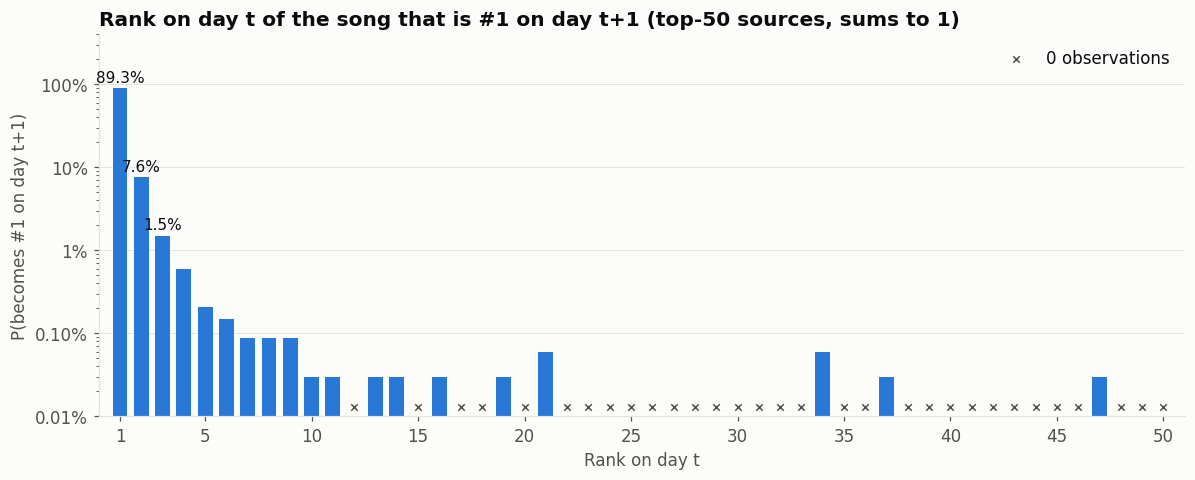

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
nz = dist[dist["count"] > 0]
z = dist[dist["count"] == 0]
ax.bar(nz["prev_rank"], nz["prob"], width=0.7, color=BLUE, zorder=2)
ax.set_yscale("log")
ax.set_ylim(1e-4, 4)
ax.scatter(z["prev_rank"], np.full(len(z), 1.3e-4), marker="x", s=18, color=INK2, linewidths=1, zorder=3, label="0 observations")
for _, r in nz.head(3).iterrows():
    ax.annotate(f"{r.prob:.1%}", (r.prev_rank, r.prob), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=10, color=INK)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2%}" if v < 0.01 else f"{v:.0%}"))
ax.set_xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
ax.set_xlim(0, 51)
ax.set_xlabel("Rank on day t")
ax.set_ylabel("P(becomes #1 on day t+1)")
ax.set_title("Rank on day t of the song that is #1 on day t+1 (top-50 sources, sums to 1)")
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 2. Cumulative probability

How deep into yesterday's chart do you need to look to cover tomorrow's #1?

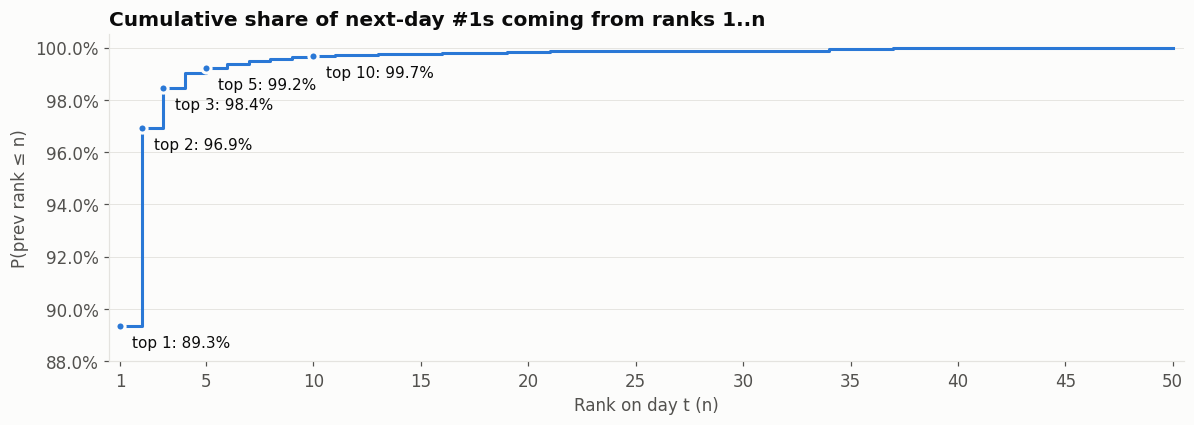

In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.step(dist["prev_rank"], dist["cum"], where="post", color=BLUE, linewidth=2)
for k in [1, 2, 3, 5, 10]:
    v = dist.loc[dist.prev_rank == k, "cum"].item()
    ax.plot(k, v, "o", color=BLUE, markersize=6, markeredgecolor=SURFACE, markeredgewidth=2, zorder=3)
    ax.annotate(f"top {k}: {v:.1%}", (k, v), xytext=(8, -14), textcoords="offset points", fontsize=10, color=INK)
ax.set_ylim(0.88, 1.005)
ax.set_xlim(0.5, 50.5)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticks([1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])
ax.set_xlabel("Rank on day t (n)")
ax.set_ylabel("P(prev rank ≤ n)")
ax.set_title("Cumulative share of next-day #1s coming from ranks 1..n")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 3. Everything outside the top-50 distribution

The 50 probabilities above condition on the #1 coming from the top 50. About 4% of new #1s weren't on the chart the day before.

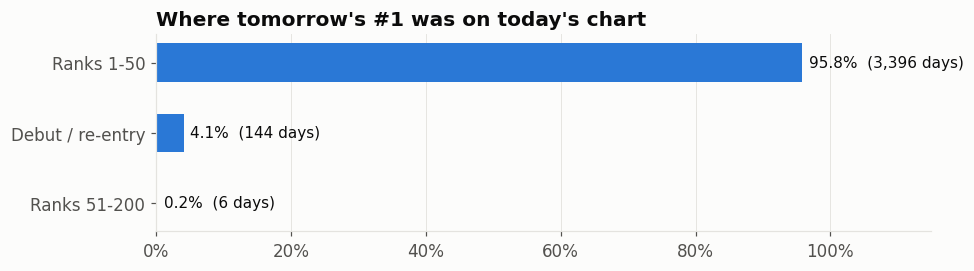

In [6]:
order = ["Ranks 1-50", "Debut / re-entry", "Ranks 51-200"]
counts = top["source"].value_counts().reindex(order)
share = counts / counts.sum()
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.barh(order[::-1], share[order[::-1]], color=BLUE, height=0.55, zorder=2)
for i, k in enumerate(order[::-1]):
    ax.text(share[k] + 0.01, i, f"{share[k]:.1%}  ({counts[k]:,} days)", va="center", fontsize=10, color=INK)
ax.set_xlim(0, 1.15)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Where tomorrow's #1 was on today's chart")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Debut #1s by weekday: they cluster on Fridays, the global release day.

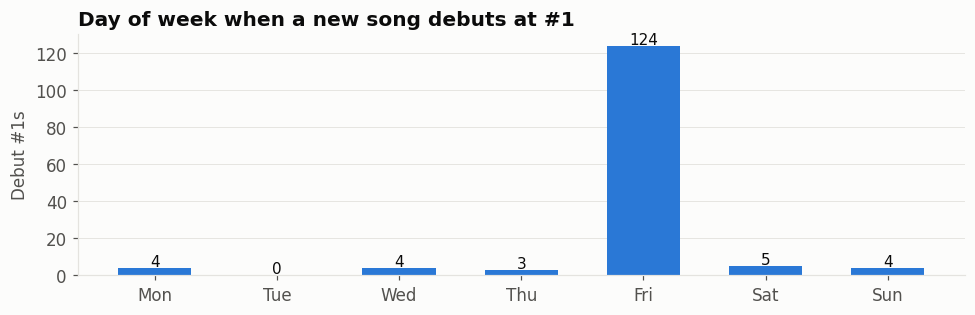

In [7]:
deb = top[top["source"] == "Debut / re-entry"]
wd = deb["chart_date"].dt.day_name().value_counts().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"], fill_value=0)
fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(wd.index.str[:3], wd.values, color=BLUE, width=0.6, zorder=2)
for i, v in enumerate(wd.values):
    ax.text(i, v + 1, str(v), ha="center", fontsize=10, color=INK)
ax.set_ylabel("Debut #1s")
ax.set_title("Day of week when a new song debuts at #1")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## 4. Is it stable over time?

Share of next-day #1s that were already #1 (i.e. the #1 held), by year. The 2017-2021 vs 2026 distribution shift matters if you pool all years.

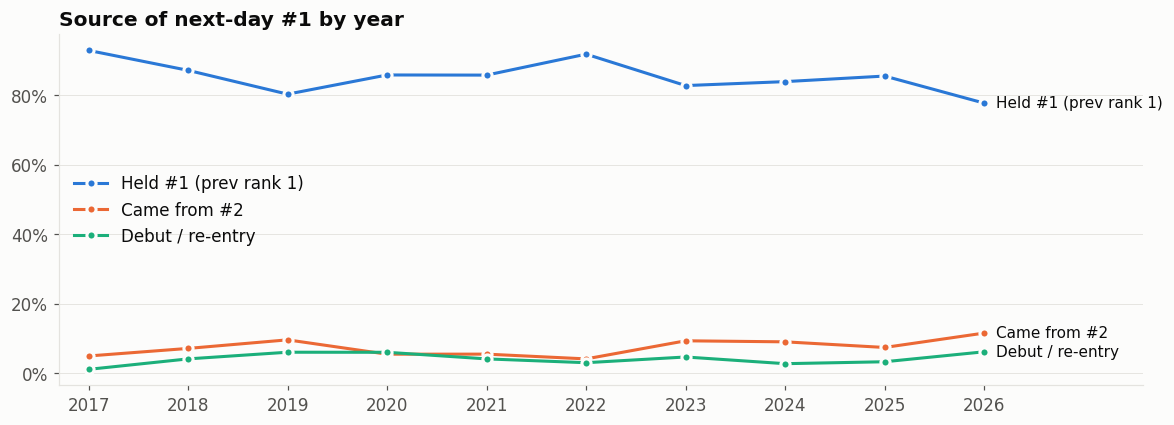

,held,from_2,debut
year,,,
2017,0.929,0.049,0.011
2018,0.871,0.071,0.041
2019,0.803,0.096,0.060
2020,0.858,0.055,0.060
2021,0.858,0.055,0.041
2022,0.918,0.041,0.030
2023,0.827,0.093,0.047
2024,0.839,0.090,0.027
2025,0.855,0.074,0.033


In [8]:
top["year"] = top["chart_date"].dt.year
yr = top.groupby("year").agg(
    held=("prev_rank", lambda s: (s == 1).mean()),
    from_2=("prev_rank", lambda s: (s == 2).mean()),
    debut=("prev_rank", lambda s: s.isna().mean()),
)
fig, ax = plt.subplots(figsize=(11, 4))
for col, c, lab in [("held", BLUE, "Held #1 (prev rank 1)"), ("from_2", ORANGE, "Came from #2"), ("debut", AQUA, "Debut / re-entry")]:
    ax.plot(yr.index, yr[col], color=c, linewidth=2, marker="o", markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=2, label=lab)
    ax.annotate(lab, (yr.index[-1], yr[col].iloc[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=10, color=INK)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xticks(yr.index)
ax.set_xlim(yr.index.min() - 0.3, yr.index.max() + 1.6)
ax.set_title("Source of next-day #1 by year")
ax.legend(frameon=False, loc="center left")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()
yr.round(3)

## 5. Longer horizons: day t to day t+h, h = 1..10

For the song that is #1 on day t+h, where was it on day t? Same 50-value distribution (normalized over ranks 1-50), one per horizon.

Linking a song across h days needs an identity that survives URI changes. Each row is linked to the previous day's row its `prev_rank` points to (a song "lineage"), skipping links where the old URI is still charting on its own that day. If the song fell off the chart in between, the lineage breaks and we fall back to matching on `track_uri`. At h = 1 this reproduces `prev_rank` exactly.

In [9]:
d = df.sort_values(["chart_date", "rank"]).reset_index(drop=True)
one = pd.Timedelta(days=1)
row_at = {(dt, r): i for i, (dt, r) in enumerate(zip(d["chart_date"], d["rank"]))}
uris_on = d.groupby("chart_date")["track_uri"].apply(set).to_dict()
lin = np.arange(len(d)); dts = d["chart_date"].tolist(); PR = d["prev_rank"].values; U = d["track_uri"].values
for i in range(len(d)):
    if PR[i] == PR[i]:
        j = row_at.get((dts[i] - one, int(PR[i])))
        if j is not None and (U[i] == U[j] or U[j] not in uris_on[dts[i]]):
            lin[i] = lin[j]
d["lineage"] = lin
assert not d.duplicated(["chart_date", "lineage"]).any()

by_lin = d[["chart_date", "lineage", "rank"]].rename(columns={"chart_date": "t0", "rank": "r_lin"})
by_uri = (d[["chart_date", "track_uri", "rank"]].rename(columns={"chart_date": "t0", "rank": "r_uri"})
          .sort_values("r_uri").drop_duplicates(["t0", "track_uri"]))
number1 = d[d["rank"] == 1][["chart_date", "lineage", "track_uri"]]

H = range(1, 11); dists = {}; summary = []
for h in H:
    q = number1.assign(t0=number1["chart_date"] - pd.Timedelta(days=h))
    q = q[q["t0"].isin(dates)]
    m = q.merge(by_lin, on=["t0", "lineage"], how="left").merge(by_uri, on=["t0", "track_uri"], how="left")
    r0 = m["r_lin"].fillna(m["r_uri"])
    c = r0[r0 <= 50].astype(int).value_counts().reindex(range(1, 51), fill_value=0)
    dists[f"h{h}"] = c / c.sum()
    summary.append({"h": h, "transitions": len(m), "top50": (r0 <= 50).mean(), "ranks_51_200": (r0 > 50).mean(),
                    "not_on_chart": r0.isna().mean(), "zero_ranks": int((c == 0).sum())})
P = pd.DataFrame(dists); P.index.name = "rank_on_day_t"
S = pd.DataFrame(summary).set_index("h")
assert np.allclose(P.sum(), 1) and np.allclose(P["h1"].values, dist["prob"].values)
P.to_csv("../data/number1_prev_rank_distribution_h1_h10.csv")
S.to_csv("../data/number1_horizon_summary.csv")
P.head(10).round(4)

,h1,h2,h3,h4,h5,h6,h7,h8,h9,h10
rank_on_day_t,,,,,,,,,,
1,0.8934,0.8427,0.8017,0.7701,0.7444,0.7262,0.7120,0.6874,0.6643,0.6482
2,0.0760,0.0989,0.1214,0.1352,0.1419,0.1473,0.1503,0.1554,0.1589,0.1619
3,0.0150,0.0266,0.0323,0.0367,0.0407,0.0390,0.0433,0.0481,0.0522,0.0585
4,0.0059,0.0113,0.0158,0.0193,0.0224,0.0232,0.0237,0.0279,0.0309,0.0293
5,0.0021,0.0049,0.0060,0.0082,0.0105,0.0112,0.0116,0.0138,0.0141,0.0156
6,0.0015,0.0034,0.0041,0.0052,0.0071,0.0084,0.0091,0.0089,0.0118,0.0140
7,0.0009,0.0012,0.0028,0.0039,0.0061,0.0077,0.0084,0.0093,0.0088,0.0094
8,0.0009,0.0021,0.0025,0.0026,0.0027,0.0053,0.0058,0.0063,0.0084,0.0078
9,0.0009,0.0012,0.0013,0.0016,0.0041,0.0049,0.0051,0.0048,0.0057,0.0062


### How the probability spreads out as the horizon grows

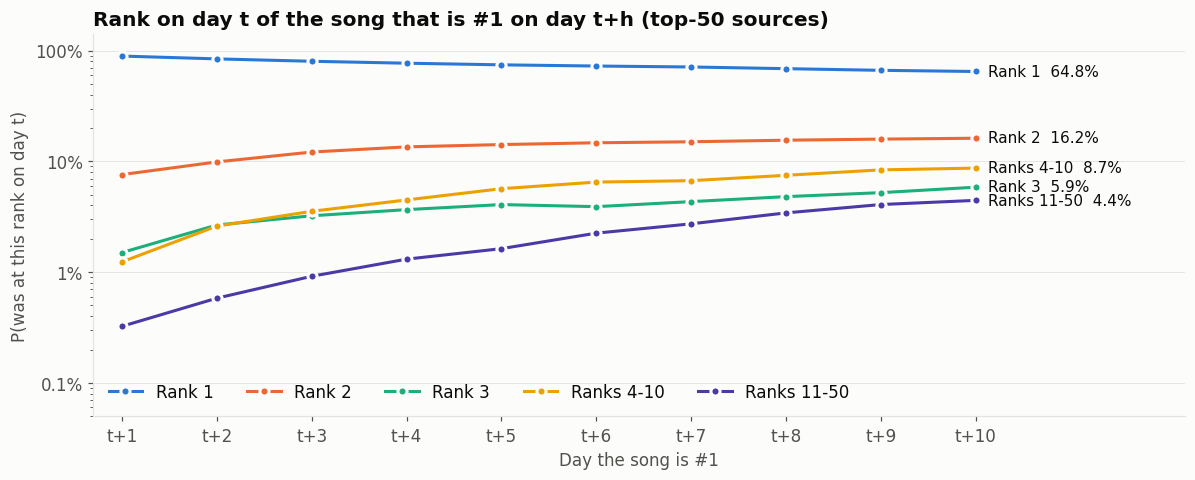

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
series = [("Rank 1", P.loc[1], BLUE), ("Rank 2", P.loc[2], ORANGE), ("Rank 3", P.loc[3], AQUA),
          ("Ranks 4-10", P.loc[4:10].sum(), "#eda100"), ("Ranks 11-50", P.loc[11:50].sum(), "#4a3aa7")]
x = list(H)
for lab, s, c in series:
    ax.plot(x, s.values, color=c, linewidth=2, marker="o", markersize=6, markeredgecolor=SURFACE, markeredgewidth=2, label=lab)
    ax.annotate(f"{lab}  {s.values[-1]:.1%}", (10, s.values[-1]), xytext=(8, 0), textcoords="offset points", va="center", fontsize=10, color=INK)
ax.set_yscale("log"); ax.set_ylim(5e-4, 1.4)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1%}" if v < 0.01 else f"{v:.0%}"))
ax.set_xticks(x); ax.set_xticklabels([f"t+{h}" for h in x]); ax.set_xlim(0.7, 12.2)
ax.set_xlabel("Day the song is #1"); ax.set_ylabel("P(was at this rank on day t)")
ax.set_title("Rank on day t of the song that is #1 on day t+h (top-50 sources)")
ax.legend(frameon=False, loc="lower left", ncol=5)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### More of the future #1s weren't on today's chart yet

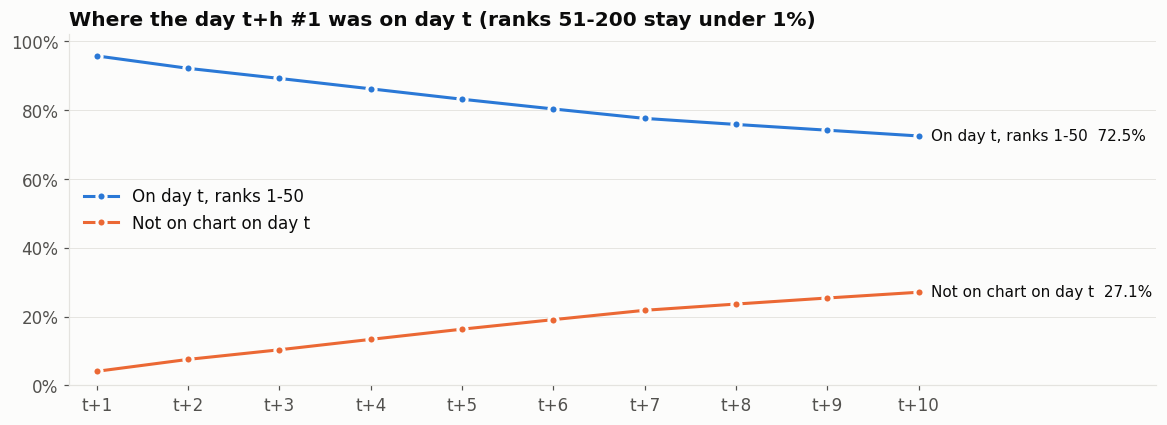

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
for col, c, lab in [("top50", BLUE, "On day t, ranks 1-50"), ("not_on_chart", ORANGE, "Not on chart on day t")]:
    ax.plot(x, S[col].values, color=c, linewidth=2, marker="o", markersize=6, markeredgecolor=SURFACE, markeredgewidth=2, label=lab)
    ax.annotate(f"{lab}  {S[col].values[-1]:.1%}", (10, S[col].values[-1]), xytext=(8, 0), textcoords="offset points", va="center", fontsize=10, color=INK)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.set_ylim(0, 1.02)
ax.set_xticks(x); ax.set_xticklabels([f"t+{h}" for h in x]); ax.set_xlim(0.7, 12.6)
ax.set_title("Where the day t+h #1 was on day t (ranks 51-200 stay under 1%)")
ax.legend(frameon=False, loc="center left")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### Summary by horizon

In [12]:
S.assign(P_rank1=P.loc[1].values, P_rank2=P.loc[2].values,
         P_top5=P.loc[1:5].sum().values, P_top10=P.loc[1:10].sum().values).round(4)

,transitions,top50,ranks_51_200,not_on_chart,zero_ranks,P_rank1,P_rank2,P_top5,P_top10
h,,,,,,,,,
1,3546,0.9577,0.0017,0.0406,31,0.8934,0.0760,0.9923,0.9968
2,3545,0.9216,0.0031,0.0753,28,0.8427,0.0989,0.9844,0.9942
3,3544,0.8922,0.0045,0.1033,23,0.8017,0.1214,0.9772,0.9908
4,3543,0.8620,0.0045,0.1335,19,0.7701,0.1352,0.9695,0.9869
5,3542,0.8317,0.0051,0.1632,17,0.7444,0.1419,0.9599,0.9837
6,3541,0.8034,0.0056,0.1909,14,0.7262,0.1473,0.9469,0.9775
7,3540,0.7760,0.0059,0.2181,13,0.7120,0.1503,0.9410,0.9727
8,3539,0.7584,0.0054,0.2362,11,0.6874,0.1554,0.9326,0.9657
9,3538,0.7417,0.0045,0.2538,11,0.6643,0.1589,0.9204,0.9592


## 6. Count-table baseline at the D-2 cutoff

Spotify's charting day runs 12:00 AM to 11:59 PM UTC, and the chart for a day is usually published by about 6 PM Eastern the next day. So before charting day D begins, the newest published chart is the one dated **D-2**. That is the information cutoff for predicting day D's #1.

The baseline is a count table: where was day D's #1 on the chart dated D-2? Used as a fixed probability forecast, it is the benchmark every later model has to beat. Its top row is the simple baseline "the #1 on D-2 is still #1 on D".

In [13]:
h = 2
q = number1.assign(t0=number1["chart_date"] - pd.Timedelta(days=h))
q = q[q["t0"].isin(dates)]
m2 = q.merge(by_lin, on=["t0", "lineage"], how="left").merge(by_uri, on=["t0", "track_uri"], how="left")
m2["r0"] = m2["r_lin"].fillna(m2["r_uri"])

def bucket(r):
    if pd.isna(r): return "Not on the chart"
    r = int(r)
    if r <= 3: return f"#{r}"
    if r <= 5: return "#4-5"
    if r <= 50: return "#6-50"
    return "#51-200"

order = ["#1", "#2", "#3", "#4-5", "#6-50", "#51-200", "Not on the chart"]
m2["position_on_D_minus_2"] = m2["r0"].apply(bucket)
baseline = m2["position_on_D_minus_2"].value_counts().reindex(order).rename("days").to_frame()
baseline["prob_number1_on_D"] = baseline["days"] / baseline["days"].sum()
assert np.isclose(baseline["prob_number1_on_D"].sum(), 1.0)
baseline.to_csv("../data/baseline_count_table_d2.csv")
print(f"Baseline 'the #1 on D-2 is #1 on D': {baseline.loc['#1', 'prob_number1_on_D']:.1%} of {len(m2):,} days")
baseline.round(4)

Baseline 'the #1 on D-2 is #1 on D': 77.7% of 3,545 days


,days,prob_number1_on_D
position_on_D_minus_2,,
#1,2753,0.7766
#2,323,0.0911
#3,87,0.0245
#4-5,53,0.0150
#6-50,51,0.0144
#51-200,11,0.0031
Not on the chart,267,0.0753


Baseline accuracy by year. Compare any model with the baseline for the same period it is tested on.

In [14]:
m2["year"] = m2["chart_date"].dt.year
by_year = m2.groupby("year").agg(
    days=("r0", "size"),
    baseline_accuracy=("r0", lambda s: (s == 1).mean()),
    number1_not_on_chart_on_D_minus_2=("r0", lambda s: s.isna().mean()),
)
by_year.round(3)

,days,baseline_accuracy,number1_not_on_chart_on_D_minus_2
year,,,
2017,363,0.871,0.028
2018,365,0.786,0.082
2019,365,0.699,0.115
2020,366,0.803,0.090
2021,365,0.781,0.085
2022,365,0.849,0.060
2023,365,0.740,0.082
2024,366,0.721,0.057
2025,365,0.797,0.060


## 7. Part 1: does the #1 hold? Logistic regression on the lead

Take the #1 on the chart dated D-2. The model predicts whether that same song is #1 on day D.

- **Predictor:** the #1's stream lead over #2 on D-2, `streams(#1) / streams(#2) - 1`.
- **Target:** `hold` = 1 if the D-2 #1 is #1 on day D, else 0.
- **Model:** `P(hold) = sigmoid(a + b * x)`, fitted by maximum likelihood (no regularisation). Two versions: `x = lead` and `x = log(lead)`.
- **Split:** train on 2017-2023, test on 2024-2026. The benchmark is a constant forecast equal to the training hold rate.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, brier_score_loss, roc_auc_score

top2 = d[d["rank"] <= 2].pivot(index="chart_date", columns="rank", values="streams")
lead_by_day = top2[1] / top2[2] - 1               # the #1's stream lead over #2, as a fraction

p1 = m2[["chart_date", "t0", "r0"]].copy()
p1["lead"] = p1["t0"].map(lead_by_day)             # lead on the chart dated D-2
p1["log_lead"] = np.log(p1["lead"].clip(lower=1e-3))
p1["hold"] = (p1["r0"] == 1).astype(int)           # 1 if the D-2 #1 is also #1 on day D

train = p1[p1["chart_date"] < "2024-01-01"]
test = p1[p1["chart_date"] >= "2024-01-01"]
print(f"train 2017-2023: {len(train):,} days, hold rate {train['hold'].mean():.1%}")
print(f"test  2024-2026: {len(test):,} days, hold rate {test['hold'].mean():.1%}")

def score(name, prob, a=np.nan, b=np.nan):
    return {"model": name, "a": a, "b": b,
            "test_log_loss": log_loss(test["hold"], prob),
            "test_brier": brier_score_loss(test["hold"], prob),
            "test_accuracy": ((prob >= 0.5) == test["hold"]).mean(),
            "test_auc": roc_auc_score(test["hold"], prob) if np.ptp(prob) > 0 else np.nan,
            "days_predicted_to_change": int((prob < 0.5).sum())}

models = {}
rows = [score("Constant (train hold rate)", np.full(len(test), train["hold"].mean()))]
for name, col in [("Lead", "lead"), ("Log lead", "log_lead")]:
    mdl = LogisticRegression(C=1e9, max_iter=1000).fit(train[[col]], train["hold"])   # C=1e9: effectively no regularisation
    models[col] = mdl
    test = test.assign(**{"p_" + col: mdl.predict_proba(test[[col]])[:, 1]})
    rows.append(score(name, test["p_" + col].values, mdl.intercept_[0], mdl.coef_[0][0]))
results = pd.DataFrame(rows).set_index("model")
results.round(4)

train 2017-2023: 2,554 days, hold rate 79.0%
test  2024-2026: 991 days, hold rate 74.3%


,a,b,test_log_loss,test_brier,test_accuracy,test_auc,days_predicted_to_change
model,,,,,,,
Constant (train hold rate),NaN,NaN,0.5766,0.1933,0.7427,NaN,0
Lead,0.5285,3.7498,0.5276,0.1731,0.7427,0.7352,0
Log lead,2.5302,0.5854,0.5203,0.1725,0.7467,0.7352,50


### Fitted curves against what happened in the test years\n\nCurves are fitted on 2017-2023. Dots are observed hold rates in 2024-2026, in ten equal-sized groups of days ordered by lead.

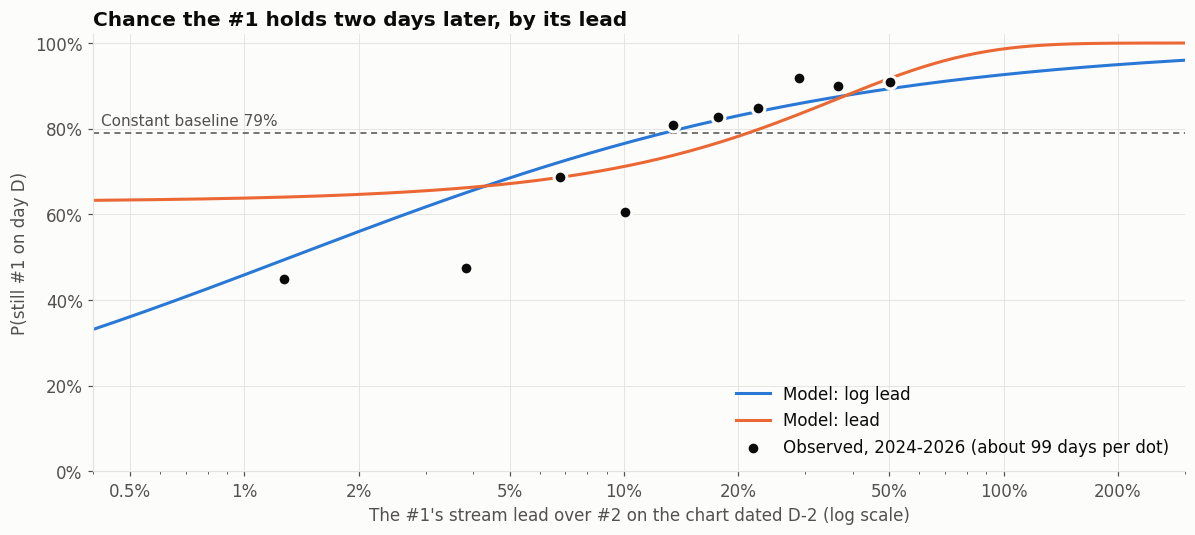

In [16]:
grid = np.logspace(np.log10(0.004), np.log10(3), 300)
curve_lead = models["lead"].predict_proba(pd.DataFrame({"lead": grid}))[:, 1]
curve_log = models["log_lead"].predict_proba(pd.DataFrame({"log_lead": np.log(grid)}))[:, 1]
bins = test.assign(g=pd.qcut(test["lead"], 10)).groupby("g", observed=True).agg(lead=("lead", "median"), hold=("hold", "mean"), days=("hold", "size"))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(grid, curve_log, color=BLUE, linewidth=2, label="Model: log lead", zorder=2)
ax.plot(grid, curve_lead, color=ORANGE, linewidth=2, label="Model: lead", zorder=2)
ax.scatter(bins["lead"], bins["hold"], s=70, color=INK, edgecolor=SURFACE, linewidth=2, zorder=3, label="Observed, 2024-2026 (about 99 days per dot)")
ax.axhline(train["hold"].mean(), color=INK2, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.annotate(f"Constant baseline {train['hold'].mean():.0%}", (0.0042, train["hold"].mean()), xytext=(0, 5), textcoords="offset points", fontsize=10, color=INK2)
ax.set_xscale("log")
ax.set_xticks([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1%}" if v < 0.01 else f"{v:.0%}"))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.02); ax.set_xlim(0.004, 3)
ax.set_xlabel("The #1's stream lead over #2 on the chart dated D-2 (log scale)")
ax.set_ylabel("P(still #1 on day D)")
ax.set_title("Chance the #1 holds two days later, by its lead")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

### Calibration on the test years, by size of lead

In [17]:
bucket = pd.cut(test["lead"], [0, 0.02, 0.05, 0.10, 0.20, 0.40, 10],
                labels=["under 2%", "2-5%", "5-10%", "10-20%", "20-40%", "over 40%"])
calibration = test.groupby(bucket, observed=True).agg(
    days=("hold", "size"), observed_hold=("hold", "mean"),
    predicted_lead=("p_lead", "mean"), predicted_log_lead=("p_log_lead", "mean"))
calibration.round(3)

,days,observed_hold,predicted_lead,predicted_log_lead
lead,,,,
under 2%,79,0.481,0.638,0.425
2-5%,113,0.451,0.659,0.633
5-10%,152,0.645,0.692,0.731
10-20%,261,0.785,0.746,0.801
20-40%,274,0.891,0.833,0.857
over 40%,112,0.893,0.921,0.896


In [18]:
flagged = test[test["p_log_lead"] < 0.5]
changes = test[test["hold"] == 0]
print(f"Log-lead model predicts a change on {len(flagged)} of {len(test)} test days; the #1 did change on {(flagged['hold'] == 0).sum()} of them.")
print(f"The #1 changed on {len(changes)} test days in total, so the model flags {(changes['p_log_lead'] < 0.5).sum()} of {len(changes)}.")
b = models["log_lead"].coef_[0][0]
print(f"Doubling the lead multiplies the odds of holding by {2 ** b:.2f}.")

Log-lead model predicts a change on 50 of 991 test days; the #1 did change on 27 of them.
The #1 changed on 255 test days in total, so the model flags 27 of 255.
Doubling the lead multiplies the odds of holding by 1.50.


## 8. Does momentum help? The growth gap over 1 to 10 days

**Growth gap over k days** = growth in the current #2's streams minus growth in the current #1's streams, both measured from k days earlier up to the chart dated D-2 (as log growth). Positive means #2 has been gaining on #1.

For each window k = 1..10, fit `hold ~ log_lead + growth_gap_k` on 2017-2023 and check:

- the coefficient and its p-value (standard errors clustered by the #1 song, because consecutive days involve the same songs),
- the same with the growth gap capped at +/-50%, since a few extreme values come from brand-new songs,
- test log loss on 2024-2026, against the log-lead-only model on the same days.

A window is only usable on days when both songs were already on the chart k days earlier.

In [19]:
import statsmodels.api as sm

S_lin = d.set_index(["chart_date", "lineage"])["streams"]
S_uri = (d.sort_values("rank").drop_duplicates(["chart_date", "track_uri"])
          .set_index(["chart_date", "track_uri"])["streams"])

def streams_k_days_ago(rows, k):
    t = rows["chart_date"] - pd.Timedelta(days=k)
    a = S_lin.reindex(pd.MultiIndex.from_arrays([t, rows["lineage"]])).values
    b = S_uri.reindex(pd.MultiIndex.from_arrays([t, rows["track_uri"]])).values
    return pd.Series(np.where(np.isnan(a), b, a), index=rows.index)

first = d[d["rank"] == 1].set_index("chart_date", drop=False)
second = d[d["rank"] == 2].set_index("chart_date", drop=False)
gap = pd.DataFrame({"song1": first["lineage"]})
for k in range(1, 11):
    growth1 = np.log(first["streams"] / streams_k_days_ago(first, k))
    growth2 = np.log(second["streams"] / streams_k_days_ago(second, k))
    gap[f"g{k}"] = growth2 - growth1               # positive = #2 gaining on #1 over the last k days

p2 = p1.join(gap, on="t0")
train2 = p2[p2["chart_date"] < "2024-01-01"]
test2 = p2[p2["chart_date"] >= "2024-01-01"]

def fit_logit(data, cols):
    return sm.Logit(data["hold"], sm.add_constant(data[cols])).fit(
        disp=0, cov_type="cluster", cov_kwds={"groups": data["song1"]})

def test_log_loss(model, data, cols):
    return log_loss(data["hold"], model.predict(sm.add_constant(data[cols], has_constant="add")))

rows = []
for k in range(1, 11):
    g = f"g{k}"
    tr = train2.dropna(subset=[g]).copy(); tr["g_capped"] = tr[g].clip(-0.5, 0.5)
    te = test2.dropna(subset=[g]).copy(); te["g_capped"] = te[g].clip(-0.5, 0.5)
    raw = fit_logit(tr, ["log_lead", g])
    cap = fit_logit(tr, ["log_lead", "g_capped"])
    base = fit_logit(tr, ["log_lead"])
    lo, hi = cap.conf_int().loc["g_capped"]
    rows.append({"window_days": k, "train_days": len(tr), "test_days": len(te),
                 "p_value_raw": raw.pvalues[g],
                 "coef_capped": cap.params["g_capped"], "ci_low": lo, "ci_high": hi, "p_value_capped": cap.pvalues["g_capped"],
                 "test_log_loss_with_gap": test_log_loss(cap, te, ["log_lead", "g_capped"]),
                 "test_log_loss_lead_only": test_log_loss(base, te, ["log_lead"])})
momentum = pd.DataFrame(rows).set_index("window_days")
momentum["test_change"] = momentum["test_log_loss_with_gap"] - momentum["test_log_loss_lead_only"]
momentum.round(4)

,train_days,test_days,p_value_raw,coef_capped,ci_low,ci_high,p_value_capped,test_log_loss_with_gap,test_log_loss_lead_only,test_change
window_days,,,,,,,,,,
1,2390,941,0.2797,-1.4149,-2.5495,-0.2804,0.0145,0.4971,0.4973,-0.0002
2,2248,902,0.4596,-0.7175,-1.6217,0.1868,0.1199,0.4973,0.4954,0.0019
3,2134,871,0.1622,-0.9831,-1.7645,-0.2017,0.0137,0.4939,0.4907,0.0031
4,2013,840,0.2445,-0.8451,-1.6699,-0.0204,0.0446,0.4876,0.4859,0.0017
5,1903,804,0.1790,-0.9801,-1.7364,-0.2238,0.0111,0.4848,0.4838,0.0010
6,1798,769,0.2648,-0.9793,-1.7170,-0.2416,0.0093,0.4705,0.4705,0.0000
7,1703,735,0.0383,-1.2217,-1.9713,-0.4721,0.0014,0.4689,0.4665,0.0024
8,1641,711,0.0558,-1.0918,-1.8073,-0.3762,0.0028,0.4684,0.4618,0.0066
9,1574,689,0.0618,-0.9177,-1.5927,-0.2427,0.0077,0.4727,0.4634,0.0094


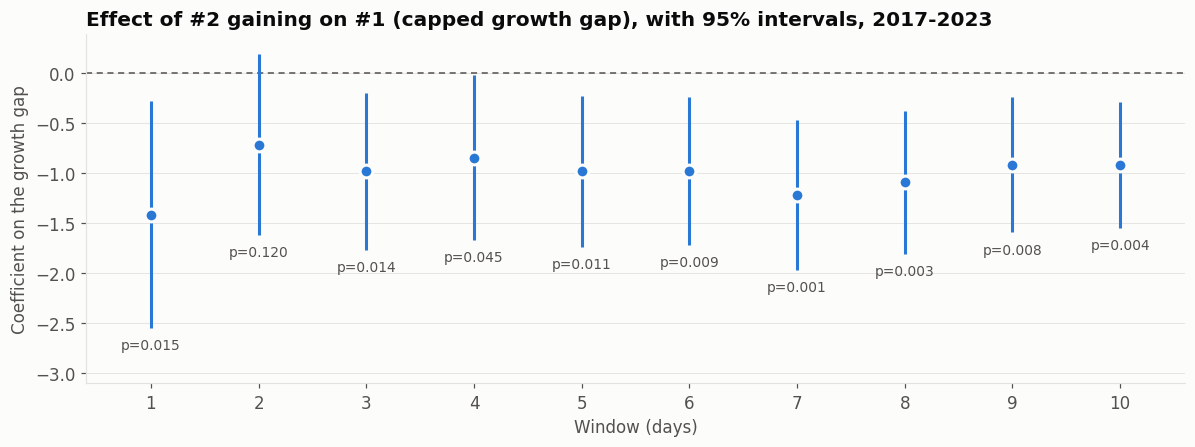

In [20]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ks = momentum.index.values
ax.axhline(0, color=INK2, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.vlines(ks, momentum["ci_low"], momentum["ci_high"], color=BLUE, linewidth=2, zorder=2)
ax.scatter(ks, momentum["coef_capped"], s=70, color=BLUE, edgecolor=SURFACE, linewidth=2, zorder=3)
for k, r in momentum.iterrows():
    ax.annotate(f"p={r.p_value_capped:.3f}", (k, r.ci_low), xytext=(0, -14), textcoords="offset points", ha="center", fontsize=9, color=INK2)
ax.set_xticks(ks); ax.set_xlim(0.4, 10.6)
ax.set_ylim(momentum["ci_low"].min() - 0.55, max(0.3, momentum["ci_high"].max() + 0.2))
ax.set_xlabel("Window (days)")
ax.set_ylabel("Coefficient on the growth gap")
ax.set_title("Effect of #2 gaining on #1 (capped growth gap), with 95% intervals, 2017-2023")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

Raw check, all years: how often the #1 held, by lead size and 7-day momentum (growth gap above +5%, below -5%, or in between).

In [21]:
x = p2.dropna(subset=["g7"]).copy()
x["momentum_7d"] = np.where(x["g7"] > 0.05, "#2 gaining", np.where(x["g7"] < -0.05, "#1 pulling away", "flat"))
x["lead_size"] = pd.cut(x["lead"], [0, 0.05, 0.20, 10], labels=["under 5%", "5-20%", "over 20%"])
order_m = ["#2 gaining", "flat", "#1 pulling away"]
hold_rate = x.pivot_table(index="lead_size", columns="momentum_7d", values="hold", aggfunc="mean", observed=True)[order_m]
days = x.pivot_table(index="lead_size", columns="momentum_7d", values="hold", aggfunc="size", observed=True)[order_m]
display(hold_rate.round(3)); days

momentum_7d,#2 gaining,flat,#1 pulling away
lead_size,,,
under 5%,0.411,0.561,0.650
5-20%,0.687,0.811,0.785
over 20%,0.938,0.916,0.930


momentum_7d,#2 gaining,flat,#1 pulling away
lead_size,,,
under 5%,141,139,137
5-20%,339,243,344
over 20%,373,335,387


## 9. Part 1 with a debut flag

Adds one yes/no input to the log-lead model:

- **`debut`** = 1 if the #1 on the chart dated D-2 is on its first-ever day on the chart (`days_on_chart == 1`), else 0.

`P(hold) = sigmoid(a + b * log(lead) + c * debut)`. Same split as before: train 2017-2023, test 2024-2026.

In [22]:
p3 = p2.assign(debut=(p2["t0"].map(first["days_on_chart"]) == 1).astype(int))
train3 = p3[p3["chart_date"] < "2024-01-01"]
test3 = p3[p3["chart_date"] >= "2024-01-01"]
print(f"debut days: {train3['debut'].sum()} of {len(train3):,} in train, {test3['debut'].sum()} of {len(test3):,} in test")

def evaluate(name, prob, data):
    change = data["hold"] == 0
    return {"model": name,
            "test_log_loss": log_loss(data["hold"], prob),
            "test_brier": brier_score_loss(data["hold"], prob),
            "test_accuracy": ((prob >= 0.5) == data["hold"]).mean(),
            "days_predicted_to_change": int((prob < 0.5).sum()),
            "changes_caught": int(((prob < 0.5) & change).sum()),
            "change_days": int(change.sum())}

m_lead = fit_logit(train3, ["log_lead"])
m_debut = fit_logit(train3, ["log_lead", "debut"])
pred_const = pd.Series(train3["hold"].mean(), index=test3.index)
pred_lead = m_lead.predict(sm.add_constant(test3[["log_lead"]], has_constant="add"))
pred_debut = m_debut.predict(sm.add_constant(test3[["log_lead", "debut"]], has_constant="add"))
test3 = test3.assign(p_lead_only=pred_lead, p_with_debut=pred_debut)

comparison = pd.DataFrame([evaluate("Constant (train hold rate)", pred_const, test3),
                           evaluate("Log lead", pred_lead, test3),
                           evaluate("Log lead + debut", pred_debut, test3)]).set_index("model")
display(comparison.round(4))
pd.DataFrame({"coefficient": m_debut.params, "p_value": m_debut.pvalues,
              "odds_multiplier": np.exp(m_debut.params)}).round(4)

debut days: 107 of 2,554 in train, 38 of 991 in test


,test_log_loss,test_brier,test_accuracy,days_predicted_to_change,changes_caught,change_days
model,,,,,,
Constant (train hold rate),0.5766,0.1933,0.7427,0,0,255
Log lead,0.5203,0.1725,0.7467,50,27,255
Log lead + debut,0.5067,0.1679,0.7548,64,38,255


,coefficient,p_value,odds_multiplier
const,2.6402,0.0,14.0162
log_lead,0.5948,0.0,1.8127
debut,-1.5719,0.0,0.2077


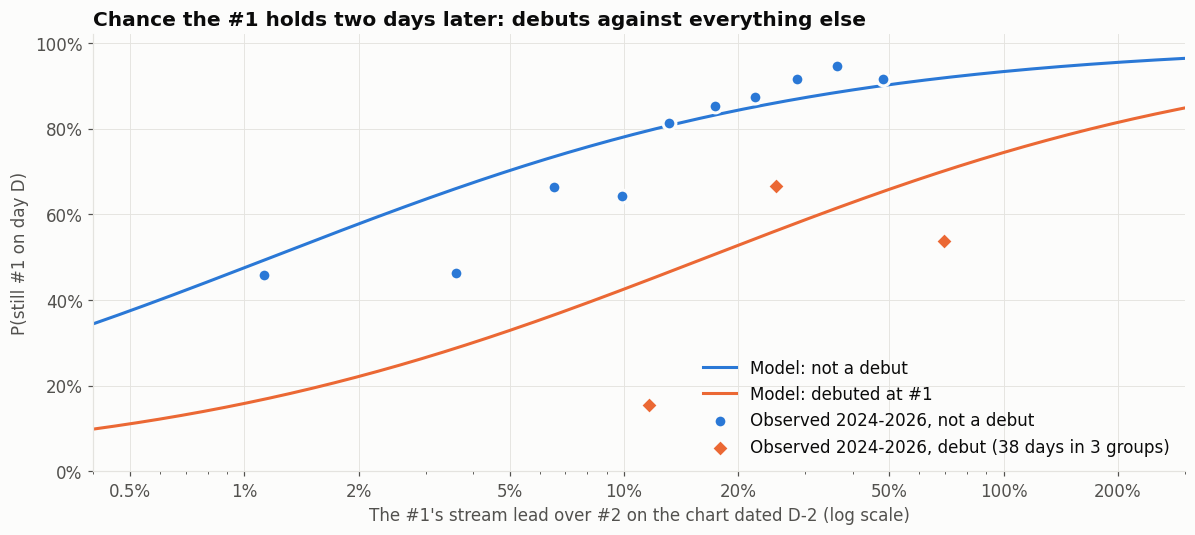

In [23]:
grid = np.logspace(np.log10(0.004), np.log10(3), 300)
def curve(flag):
    X = sm.add_constant(pd.DataFrame({"log_lead": np.log(grid), "debut": flag}), has_constant="add")
    return m_debut.predict(X)

def observed(data, groups):
    return data.assign(g=pd.qcut(data["lead"], groups)).groupby("g", observed=True).agg(lead=("lead", "median"), hold=("hold", "mean"))

obs_no = observed(test3[test3["debut"] == 0], 10)
obs_yes = observed(test3[test3["debut"] == 1], 3)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(grid, curve(0), color=BLUE, linewidth=2, label="Model: not a debut", zorder=2)
ax.plot(grid, curve(1), color=ORANGE, linewidth=2, label="Model: debuted at #1", zorder=2)
ax.scatter(obs_no["lead"], obs_no["hold"], s=70, color=BLUE, edgecolor=SURFACE, linewidth=2, zorder=3, label="Observed 2024-2026, not a debut")
ax.scatter(obs_yes["lead"], obs_yes["hold"], s=70, color=ORANGE, marker="D", edgecolor=SURFACE, linewidth=2, zorder=3, label=f"Observed 2024-2026, debut ({int(test3['debut'].sum())} days in 3 groups)")
ax.set_xscale("log")
ax.set_xticks([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1%}" if v < 0.01 else f"{v:.0%}"))
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_ylim(0, 1.02); ax.set_xlim(0.004, 3)
ax.set_xlabel("The #1's stream lead over #2 on the chart dated D-2 (log scale)")
ax.set_ylabel("P(still #1 on day D)")
ax.set_title("Chance the #1 holds two days later: debuts against everything else")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

Calibration on the test years, split by the flag.

In [24]:
calib = test3.groupby(test3["debut"].map({0: "not a debut", 1: "debuted at #1"})).agg(
    days=("hold", "size"), observed_hold=("hold", "mean"),
    predicted_lead_only=("p_lead_only", "mean"), predicted_with_debut=("p_with_debut", "mean"))
calib.round(3)

,days,observed_hold,predicted_lead_only,predicted_with_debut
debut,,,,
debuted at #1,38,0.447,0.836,0.558
not a debut,953,0.754,0.765,0.778


## The full table

In [25]:
dist.round(4)

,prev_rank,count,prob,cum
0,1,3034,0.8934,0.8934
1,2,258,0.0760,0.9694
2,3,51,0.0150,0.9844
3,4,20,0.0059,0.9903
4,5,7,0.0021,0.9923
5,6,5,0.0015,0.9938
6,7,3,0.0009,0.9947
7,8,3,0.0009,0.9956
8,9,3,0.0009,0.9965
9,10,1,0.0003,0.9968
